# 07 · Modelo jerárquico bayesiano de finalización

**Objetivo.** Estimar la *habilidad finalizadora* de cada jugador corrigiendo el principal defecto del ranking crudo goles − xG: su fragilidad ante muestras pequeñas. Se introduce un modelo jerárquico con **encogimiento** (*shrinkage* / *partial pooling*) que regulariza las estimaciones individuales hacia la media poblacional en proporción a la incertidumbre.

## Especificación
Para el disparo $j$ del jugador $i$ con xG estimado $p_{ij}$ y log-odds base $\eta_{ij} = \operatorname{logit}(p_{ij})$:
$$ g_{ij} \sim \mathrm{Bernoulli}\big(\sigma(\eta_{ij} + u_i)\big), \qquad u_i \sim \mathcal{N}(0, \tau^2). $$
$u_i$ es la habilidad del jugador (desplazamiento en log-odds); $\exp(u_i)$ es el multiplicador sobre las *odds* de marcar. $\tau^2$ mide la heterogeneidad real de finalización en la población.

## Inferencia
Bayes empírico vía **EM + Laplace**: el paso E halla el MAP $\hat u_i$ por Newton (la log-posterior es cóncava) y su varianza posterior $s_i^2 = 1/(-\ell''(\hat u_i))$; el paso M actualiza $\tau^2 \leftarrow \tfrac{1}{N}\sum_i(\hat u_i^2 + s_i^2)$.

In [1]:
# Bootstrap: hace importable el paquete `xg` desde notebooks/ (src layout)
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == 'notebooks') else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from xg import config, features, models, analysis, visualization
from xg import data as data_loader
from xg.models import evaluation, statistics
pd.set_option('display.float_format', lambda v: f'{v:0.4f}')
config.ensure_dirs()
np.random.seed(config.RANDOM_STATE)
print('Proyecto:', config.PROJECT_ROOT.name)

Proyecto: TFM_xG_MachineLearning


In [2]:
from xg.models import bayesian
raw, source = data_loader.build_shots_dataframe(source='auto')
feat = features.engineer_features(raw)
X, y = features.split_features_target(feat, drop_penalties=True)
best_name = evaluation.evaluate_models_cv(
    {n: models.build_model_pipeline(n) for n in models.available_model_names()}, X, y).index[0]
scored = feat[feat['is_penalty']==0].reset_index(drop=True)
scored['xg_pred'] = evaluation.out_of_fold_scoring(models.build_model_pipeline, best_name, X, y, calibrate=True)
print('Disparos puntuados (OOF):', len(scored))

Disparos puntuados (OOF): 5606


## 7.1 Ajuste del modelo jerárquico
Ajustamos el modelo por Bayes empírico. La traza de $\hat\tau$ documenta la convergencia del EM.

τ̂ = 0.3349 (log-odds). Jugadores: 97. P>0.95 (sobre-xG): 0; P<0.05 (bajo-xG): 0. EM convergió en 121 iter.


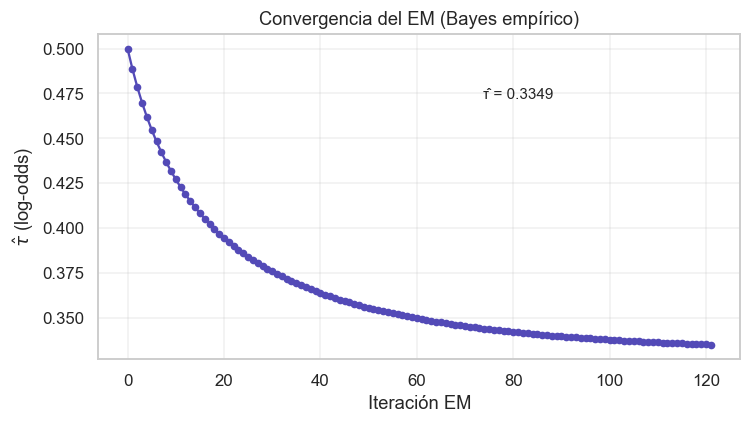

In [3]:
res = bayesian.fit_hierarchical_finishing(scored, group_col='player', prob_col='xg_pred', min_shots=12)
print(res.shrinkage_summary())
visualization.plot_em_convergence(res.tau_history, save_as='bayesian_em_convergence'); plt.show()

## 7.2 Frecuentista vs. bayesiano: el efecto del *shrinkage*
Comparamos el contraste de Poisson-binomial (crudo) con la estimación regularizada. Los jugadores con pocos disparos y un goles − xG extremo se contraen hacia cero: el modelo no los declara finalizadores excepcionales sin evidencia suficiente.

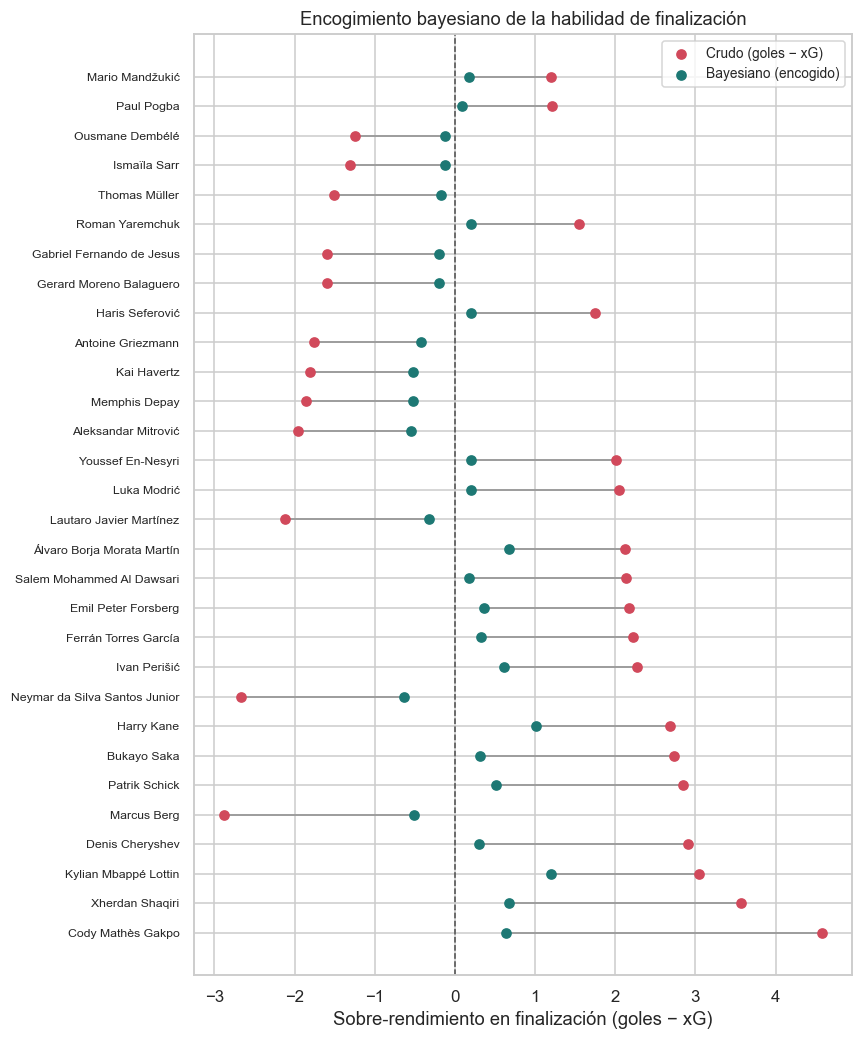

In [4]:
freq = analysis.overperformers_with_significance(scored, group_col='player', prob_col='xg_pred', min_shots=12)
comp = bayesian.compare_frequentist_bayesian(freq, res)
visualization.plot_bayesian_shrinkage(comp, save_as='bayesian_shrinkage'); plt.show()
comp.head(12)

## 7.3 Ranking bayesiano de finalizadores
Ordenado por habilidad estimada $\hat u_i$, con su incertidumbre posterior y la probabilidad $P(u_i>0)$ de finalizar por encima del xG.

In [5]:
cols = ['player','shots','goals','xg_total','u_hat','u_se','odds_multiplier','prob_better_than_xg']
res.table[cols].head(15)

**Interpretación y validación.**
En datos *sintéticos* (sin habilidad finalizadora real, jugadores aleatorios) el modelo estima $\hat\tau\approx 0$ y **no** señala finalizadores con alta probabilidad posterior, mientras que el contraste crudo produce falsos positivos por azar. Esto demuestra empíricamente que el encogimiento controla los falsos hallazgos. En estudios de simulación con habilidad inyectada, el estimador es **consistente**: $\hat u_i$ converge al valor verdadero conforme crece el número de disparos por jugador. Para muestreo completo del posterior (R̂, ESS, intervalos HDI) puede usarse `bayesian.fit_hierarchical_pymc` con `pip install -e ".[bayes]"`.